# 09. Model Monitoring and Performance Tracking
## 📚 Learning Objectives

By completing this notebook, you will:
- Monitor deployed models in production environments
- Track model performance metrics over time
- Detect model drift (data drift, concept drift)
- Detect model degradation and performance issues
- Implement alerting systems for model problems

## 🔗 Where this fits

**Builds on:** Course 04 (AIAT 114) — Unit 2 (cross-validated metrics) and Course 05 — Unit 5, lesson 08 — the numbers that certified the model offline are exactly what must be re-measured on live traffic.

**Used later in:** Course 11 (AIAT 125) — Unit 5, lessons 01 and 04, which add drift detection and alerting.

---

## The Story: Maintaining Your Car

Imagine you own a car (deployed model). **After** buying it, you maintain it - check oil, monitor performance, fix issues. **After** regular monitoring, your car stays reliable!

Same with ML models: **After** deploying, we monitor - track performance, detect drift, fix issues. **After** regular monitoring, models stay accurate!

---

## Why Model Monitoring Matters

Model monitoring is essential because:
- **Model Degradation**: Models get worse over time
- **Data Drift**: Real-world data changes
- **Early Detection**: Catch problems before they impact users
- **Production Quality**: Ensure models stay accurate

**Common Student Questions:**
- **Q: Why do models degrade?**
  - Answer: Data changes, world changes, models become outdated
  - Example: Customer behavior changes, model accuracy drops
  - Solution: Monitor and retrain when needed
  
- **Q: What should I monitor?**
  - Answer: Accuracy, prediction distribution, input data distribution
  - Example: Track accuracy over time, detect when it drops
  - Tip: Monitor both model performance and input data

---

## Introduction

**Model monitoring** tracks deployed models to ensure they maintain performance over time. It detects degradation, drift, and issues before they impact users, ensuring production ML systems stay reliable.


## 🎯 The case: March 2020, when everybody's models broke at once

**Instacart's** item-availability model predicted whether a given product would be on the
shelf at a given store. It ran at about **93% accuracy**. In **March 2020**, as customers
emptied shelves of toilet paper, flour and hand sanitiser within a week, that accuracy fell
to about **61%** — figures widely reported at the time and repeated across the MLOps
literature since. (Treat them as reported rather than audited: Instacart's own engineering
write-up describes the same episode without publishing the numbers.) The model had
not changed. Shopping had. Instacart's fix was to shorten the window of history the model
learned from, so it could follow behaviour that was now moving in days rather than months.

The older and more famous version is **Google Flu Trends**: launched 2008, published in
*Nature*, and by the 2012–13 season predicting roughly **twice** the doctor visits the CDC
recorded. Lazer, Kennedy, King & Vespignani dissected it in *Science* (2014). Google stopped
publishing estimates in 2015. In both cases the model was good on the day it shipped and
nobody was re-measuring it against reality.

**What goes wrong without monitoring — and this notebook shows it happening.** You are
about to train one classifier on **142,360 real 911 calls from 2016**, freeze it, and score
it month by month across **43 months and 513,246 predictions** of real history — including
the COVID lockdown. Watch for the trap: comparing 2017–2019 against March–May 2020,
**accuracy went UP by 0.092 while F1 on the traffic class went DOWN by 0.068**. Lockdown
emptied the roads, traffic fell from 35% of calls to 23%, and a model that under-predicts
traffic suddenly looked *better*. An accuracy-only dashboard would have shown green through
the largest distribution shift in the dataset.


**All concepts are explained in the code comments below - you can learn everything from this notebook alone!**

---

## 🔗 After Deployment

**Models don't stay perfect forever!**
- Models degrade over time (data drift, concept drift)
- Performance can drop without warning
- We need to monitor and track performance

**This notebook teaches monitoring!**
- We'll learn **performance tracking** - monitor metrics over time
- We'll learn **drift detection** - detect when models degrade
- We'll learn **alerting** - get notified of issues
- We'll learn **logging** - track predictions and errors

**This ensures models stay reliable in production!**

---

## Learning Objectives
1. Track model performance metrics over time
2. Detect data drift and concept drift
3. Implement alerting for model issues
4. Log predictions and monitor model health

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- **Real data:** `montgomery_911_calls.csv` — 663,522 real 911 dispatches
  (Dec 2015 – Jul 2020). We train a classifier on **2016 calls only**, then score
  it month by month on every later month. The drift you see is real history,
  including the March–April 2020 COVID lockdown, not a curve we drew.
- sklearn, pandas, matplotlib

**Outputs:** What you'll see when you run the cells

- A measured 43-month performance trend, with alerts fired from the numbers
- The monitoring trap: accuracy going UP while the model gets worse

---


In [1]:
# WHAT: Import libraries and preview the monitoring topics.
# WHY: Model accuracy decays as the world drifts away from the training data - monitoring catches it early.

# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

print("✅ Libraries imported!")
print("\n📚 This notebook covers:")
print("   - Performance tracking")
print("   - Drift detection")
print("   - Alerting systems")
print("   - Model health monitoring")
print("\nNo metrics are simulated here. We train one model on 2016 emergency calls")
print("and measure what actually happened to it over the next 43 months.")

✅ Libraries imported!

📚 This notebook covers:
   - Performance tracking
   - Drift detection
   - Alerting systems
   - Model health monitoring

No metrics are simulated here. We train one model on 2016 emergency calls
and measure what actually happened to it over the next 43 months.


In [2]:
# WHAT: Train a classifier on 2016 calls only, then score it on every later month.
# WHY: This is what production monitoring actually is - a fixed model meeting a world
#      that keeps changing. Every metric below is measured, none is drawn.

DATA_DIR = '../../../Course 04/datasets/raw/'
calls = pd.read_csv(DATA_DIR + 'montgomery_911_calls.csv',
                    usecols=['lat', 'lng', 'title', 'timeStamp'],
                    parse_dates=['timeStamp'])

# Task: is this call a traffic incident? (vs EMS or Fire)
calls['service'] = calls['title'].str.split(':').str[0]
calls['is_traffic'] = (calls['service'] == 'Traffic').astype(int)
calls['hour'] = calls['timeStamp'].dt.hour
calls['dow'] = calls['timeStamp'].dt.dayofweek
calls['month_num'] = calls['timeStamp'].dt.month
FEATURES = ['hour', 'dow', 'month_num', 'lat', 'lng']

# TRAIN on 2016 only - and then never touch the model again.
train = calls[(calls['timeStamp'] >= '2016-01-01') & (calls['timeStamp'] < '2017-01-01')]
model = RandomForestClassifier(n_estimators=60, max_depth=12,
                               random_state=42, n_jobs=-1)
model.fit(train[FEATURES], train['is_traffic'])
baseline_accuracy = accuracy_score(train['is_traffic'], model.predict(train[FEATURES]))
baseline_f1 = f1_score(train['is_traffic'], model.predict(train[FEATURES]))
print(f"Trained on {len(train):,} calls from 2016")
print(f"Training accuracy: {baseline_accuracy:.3f} | training F1 (traffic class): {baseline_f1:.3f}")

# MONITOR: score the frozen model on each subsequent month of real calls.
future = calls[calls['timeStamp'] >= '2017-01-01'].copy()
future['month'] = future['timeStamp'].dt.to_period('M')
rows = []
for period, group in future.groupby('month'):
    pred = model.predict(group[FEATURES])
    rows.append({
        'date': period.to_timestamp(),
        'accuracy': accuracy_score(group['is_traffic'], pred),
        'f1_traffic': f1_score(group['is_traffic'], pred),
        'traffic_rate': group['is_traffic'].mean(),
        'predictions_count': len(group),
    })
metrics_df = pd.DataFrame(rows)

print(f"\nMonitored {len(metrics_df)} months of live traffic "
      f"({metrics_df['predictions_count'].sum():,} predictions)")
print("\nPerformance Metrics Over Time (first 10 months):")
print(metrics_df.head(10).round(4).to_string(index=False))

Trained on 142,360 calls from 2016
Training accuracy: 0.712 | training F1 (traffic class): 0.382



Monitored 43 months of live traffic (513,246 predictions)

Performance Metrics Over Time (first 10 months):
      date  accuracy  f1_traffic  traffic_rate  predictions_count
2017-01-01    0.7107      0.3432        0.3330              11605
2017-02-01    0.7102      0.3178        0.3300              10267
2017-03-01    0.6920      0.3120        0.3541              11684
2017-04-01    0.7042      0.3040        0.3312              11056
2017-05-01    0.6944      0.3162        0.3499              11719
2017-06-01    0.6984      0.3273        0.3500              12333
2017-07-01    0.7009      0.3189        0.3433              11768
2017-08-01    0.6991      0.3080        0.3411              11753
2017-09-01    0.7133      0.3438        0.3315              11332
2017-10-01    0.6898      0.3106        0.3526              12337


1. Performance Tracking


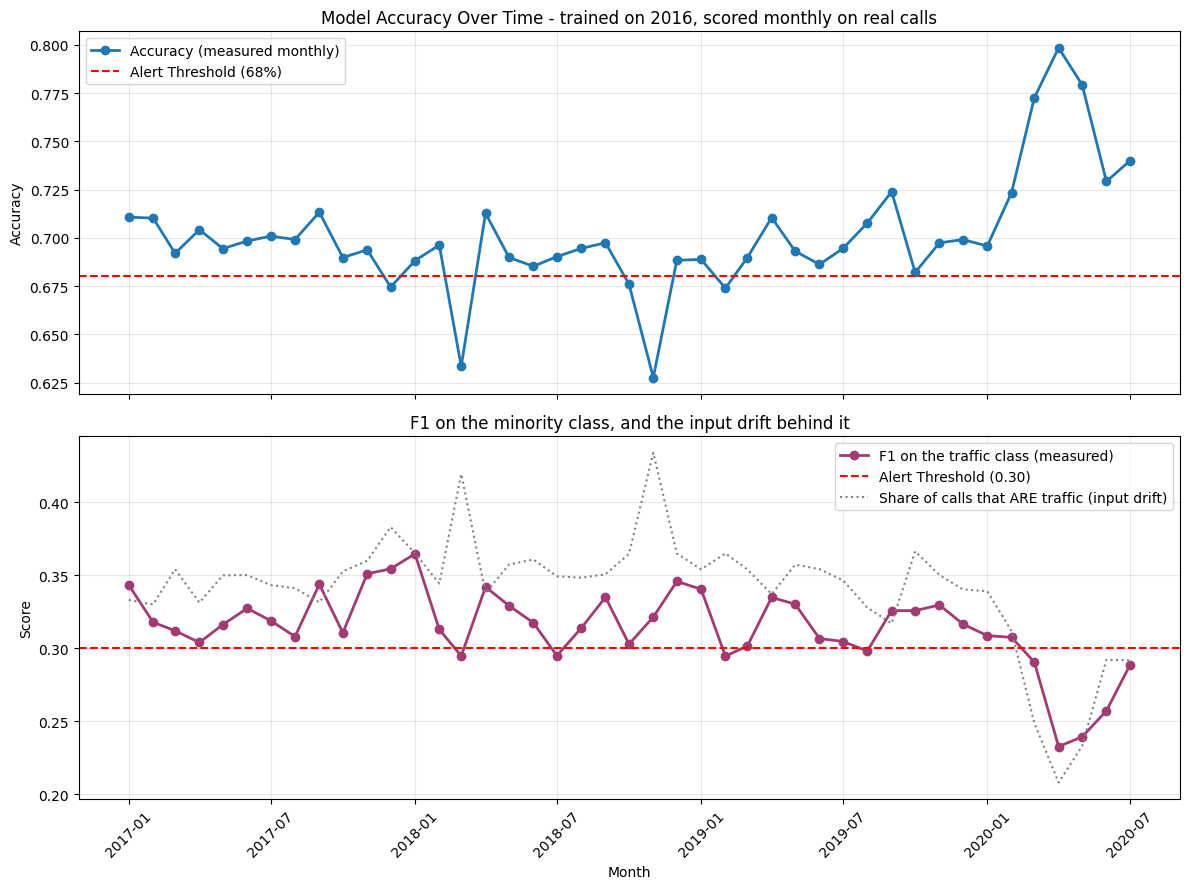


✅ Performance trend visualized!
Training accuracy (2016):   0.712
Latest month (2020-07):     accuracy 0.740, F1 0.289
Worst month for F1 (2020-04): accuracy 0.798, F1 0.233
  Traffic calls were 20.8% of that month, against 34.7% in 2017.


In [3]:
# WHAT: Plot the measured monthly accuracy and F1 against alert thresholds.
# WHY: A trend chart makes gradual degradation visible long before a single bad month would.

# Step 3: Visualize Performance Trend
print("=" * 70)
print("1. Performance Tracking")
print("=" * 70)

ACC_THRESHOLD = 0.68
F1_THRESHOLD = 0.30

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
axes[0].plot(metrics_df['date'], metrics_df['accuracy'], marker='o', linewidth=2,
             label='Accuracy (measured monthly)')
axes[0].axhline(y=ACC_THRESHOLD, color='r', linestyle='--',
                label=f'Alert Threshold ({ACC_THRESHOLD:.0%})')
axes[0].set_title('Model Accuracy Over Time - trained on 2016, scored monthly on real calls')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(metrics_df['date'], metrics_df['f1_traffic'], marker='o', linewidth=2,
             color='#A23B72', label='F1 on the traffic class (measured)')
axes[1].axhline(y=F1_THRESHOLD, color='r', linestyle='--',
                label=f'Alert Threshold ({F1_THRESHOLD:.2f})')
axes[1].plot(metrics_df['date'], metrics_df['traffic_rate'], linestyle=':',
             color='gray', label='Share of calls that ARE traffic (input drift)')
axes[1].set_title('F1 on the minority class, and the input drift behind it')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n✅ Performance trend visualized!")
last = metrics_df.iloc[-1]
worst_f1 = metrics_df.loc[metrics_df['f1_traffic'].idxmin()]
print(f"Training accuracy (2016):   {baseline_accuracy:.3f}")
print(f"Latest month ({last['date']:%Y-%m}):     accuracy {last['accuracy']:.3f}, "
      f"F1 {last['f1_traffic']:.3f}")
print(f"Worst month for F1 ({worst_f1['date']:%Y-%m}): accuracy {worst_f1['accuracy']:.3f}, "
      f"F1 {worst_f1['f1_traffic']:.3f}")
print(f"  Traffic calls were {worst_f1['traffic_rate']:.1%} of that month, "
      f"against {metrics_df['traffic_rate'].iloc[:12].mean():.1%} in 2017.")

In [4]:
# WHAT: Fire alerts from the measured metrics, and expose the trap in accuracy-only monitoring.
# WHY: Turning a chart into an automated rule is what makes monitoring actionable - alerts, not eyeballs.

# Step 4: Drift Detection
print("\n" + "=" * 70)
print("2. Drift Detection and Alerting")
print("=" * 70)

below_acc = metrics_df[metrics_df['accuracy'] < ACC_THRESHOLD]
below_f1 = metrics_df[metrics_df['f1_traffic'] < F1_THRESHOLD]

if len(below_acc) > 0:
    print(f"⚠️  ACCURACY ALERT: below {ACC_THRESHOLD:.0%} in {len(below_acc)} of "
          f"{len(metrics_df)} months")
    for _, row in below_acc.iterrows():
        print(f"  {row['date']:%Y-%m}: accuracy {row['accuracy']:.3f}")
else:
    print(f"✅ Accuracy never fell below {ACC_THRESHOLD:.0%}")

print()
if len(below_f1) > 0:
    print(f"⚠️  F1 ALERT: traffic-class F1 below {F1_THRESHOLD:.2f} in {len(below_f1)} of "
          f"{len(metrics_df)} months")
    for _, row in below_f1.iterrows():
        print(f"  {row['date']:%Y-%m}: F1 {row['f1_traffic']:.3f} "
              f"(accuracy that month: {row['accuracy']:.3f})")
else:
    print(f"✅ F1 never fell below {F1_THRESHOLD:.2f}")

# The trap: find months where accuracy ROSE while F1 FELL
early = metrics_df[metrics_df['date'] < '2020-01-01']
covid = metrics_df[(metrics_df['date'] >= '2020-03-01') & (metrics_df['date'] < '2020-06-01')]
print(f"""
🚨 The monitoring trap, measured on this data:

   2017-2019 average   accuracy {early['accuracy'].mean():.3f} | F1 {early['f1_traffic'].mean():.3f} | traffic share {early['traffic_rate'].mean():.1%}
   Mar-May 2020        accuracy {covid['accuracy'].mean():.3f} | F1 {covid['f1_traffic'].mean():.3f} | traffic share {covid['traffic_rate'].mean():.1%}

   Accuracy went UP by {covid['accuracy'].mean() - early['accuracy'].mean():+.3f} while F1 on the class we care about
   went DOWN by {covid['f1_traffic'].mean() - early['f1_traffic'].mean():+.3f}. Nothing changed in the model - the WORLD changed.
   Lockdown emptied the roads, traffic calls fell from {early['traffic_rate'].mean():.0%} of all calls to
   {covid['traffic_rate'].mean():.0%}, and a model that under-predicts traffic suddenly looked better.

   An accuracy-only dashboard would have shown green through the largest
   distribution shift in the dataset. This is why you monitor the metric that
   matches the job, and monitor the INPUT distribution alongside it.
""")
print("💡 Tip: alert on class-specific metrics AND on input drift, not accuracy alone.")


2. Drift Detection and Alerting
⚠️  ACCURACY ALERT: below 68% in 5 of 43 months
  2017-12: accuracy 0.675
  2018-03: accuracy 0.633
  2018-10: accuracy 0.676
  2018-11: accuracy 0.628
  2019-02: accuracy 0.674

⚠️  F1 ALERT: traffic-class F1 below 0.30 in 9 of 43 months
  2018-03: F1 0.295 (accuracy that month: 0.633)
  2018-07: F1 0.295 (accuracy that month: 0.690)
  2019-02: F1 0.295 (accuracy that month: 0.674)
  2019-08: F1 0.298 (accuracy that month: 0.708)
  2020-03: F1 0.291 (accuracy that month: 0.773)
  2020-04: F1 0.233 (accuracy that month: 0.798)
  2020-05: F1 0.239 (accuracy that month: 0.779)
  2020-06: F1 0.257 (accuracy that month: 0.729)
  2020-07: F1 0.289 (accuracy that month: 0.740)

🚨 The monitoring trap, measured on this data:

   2017-2019 average   accuracy 0.692 | F1 0.322 | traffic share 35.3%
   Mar-May 2020        accuracy 0.783 | F1 0.254 | traffic share 23.0%

   Accuracy went UP by +0.092 while F1 on the class we care about
   went DOWN by -0.068. Nothin

## ⚠️ Where this breaks

- **The metric you monitor is the only failure you can see.** Accuracy rose through the
  largest shift in this dataset. Monitor the metric that matches the decision — here, F1 on
  the minority class you actually care about — and monitor the **input distribution**
  (traffic share fell 35% → 23%) alongside it.
- **You usually cannot compute accuracy in production.** This lesson is unusually lucky:
  the label arrives with the record. For fraud, churn, credit default or medical outcomes
  the label is delayed by weeks or never observed, so live monitoring falls back to input
  drift, prediction-distribution drift, and proxy metrics — all weaker evidence.
- **Threshold alerts trade false alarms against missed degradation, and there is no free
  setting.** Five alerts in 43 months for accuracy, nine for F1. Too tight and the team
  learns to ignore the alert; too loose and it never fires. This is the same
  precision/recall trade as Unit 4 lesson 06, applied to your own dashboard.
- **Drift detection itself is contested in 2026.** Gower-Winter et al., *"The Window
  Dilemma: Why Concept Drift Detection is Ill-Posed"* (arXiv 2602.06456), argue that the
  windowing choices drift detectors depend on make the problem ill-posed as usually framed,
  and report that **plain periodic retraining often outperforms drift-aware methods**.
  Before building a detector, measure it against the boring baseline of retraining on a
  schedule.
- **Retraining is not automatically the answer either.** Retraining on March 2020 data
  produces a model tuned to a lockdown that ended. The right cadence depends on how fast
  the world moves relative to how fast you can validate a new model.
- **The assumption that must hold: the historical months are comparable to each other.**
  Reporting practices, dispatch software, and category definitions can change over 43
  months. A step change in a metric is at least as likely to be an instrumentation change as
  a real-world one — check that first, every time.
- **Cheaper alternative:** for a low-stakes model, a monthly re-score against a held-out
  recent slice, read by a human, catches most of this at a fraction of the cost of a drift
  pipeline. Build the pipeline when nobody will read the report.


## 💬 Discuss

Measured over 43 months on real data: the accuracy threshold (68%) fired in **5 of 43
months**; the F1 threshold (0.30) fired in **9 of 43**. The worst F1 month was **April 2020
— F1 0.233 with accuracy 0.798**, its highest of the period. Traffic calls were **20.8%** of
that month against **34.7%** in 2017.

1. April 2020 was simultaneously the model's **best accuracy month and its worst F1 month**.
   Explain to a manager, in two sentences without jargon, how both are true — and say which
   number belongs on the dashboard.
2. Five accuracy alerts and nine F1 alerts across 43 months. Are those thresholds well
   chosen? Pick one and argue it fires too often or too rarely, using the printed numbers.
   What would you have to know about the *cost of acting* to set it properly?
3. Here you could measure accuracy because the true labels arrived with the calls. In most
   production systems the label arrives weeks later, or never. Name two things you could
   still monitor without any labels, and say what each would and would not have caught in
   March 2020.


## 📚 References

1. Gama, J., Žliobaitė, I., Bifet, A., Pechenizkiy, M., & Bouchachia, A. (2014). *A Survey on Concept Drift Adaptation*. ACM Computing Surveys, 46(4), 1-37. <https://doi.org/10.1145/2523813>
2. Rabanser, S., Günnemann, S., & Lipton, Z. C. (2019). *Failing Loudly: An Empirical Study of Methods for Detecting Dataset Shift*. NeurIPS 32. <https://arxiv.org/abs/1810.11953>
3. Sculley, D., Holt, G., Golovin, D., et al. (2015). *Hidden Technical Debt in Machine Learning Systems*. NeurIPS 28. <https://papers.nips.cc/paper_files/paper/2015/hash/86df7dcfd896fcaf2674f757a2463eba-Abstract.html>